# Análisis Post-Entrenamiento
## Detectabilidad individual, señales por grupo y horizonte temporal

Este notebook responde tres preguntas:
1. **¿Para quién funciona el modelo?** — clasificación de sujetos detectables vs no detectables
2. **¿Qué distingue fisiológicamente a cada grupo?** — comparación de señales
3. **¿Cuándo antes aparece la señal?** — AUC por distancia temporal al onset

## Resultados de entrenamiento (GRU como modelo principal)
| Métrica | RF | MLP | GRU | LSTM |
|---------|-----|-----|-----|------|
| ROC-AUC | 0.658±0.291 | 0.678±0.252 | **0.699±0.234** | 0.660±0.245 |
| PR-AUC  | — | 0.460±0.243 | **0.494±0.255** | 0.452±0.261 |
| Recall  | — | 0.244±0.370 | **0.533±0.418** | 0.756±0.370 |

In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
from scipy import stats as scipy_stats
from scipy.signal import find_peaks, butter, filtfilt
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

WESAD_PATH = 'WESAD'
SUBJECTS   = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S13','S14','S15','S16','S17']
FS_10      = 10
WINDOW     = 600
STRESS     = 2
PRECURSOR_ZONE = 300

# ── AUC por sujeto de todos los modelos (pegar resultados del entrenamiento) ──
auc_by_subject = {
    'S2' : {'RF': 0.192, 'MLP': 0.139, 'GRU': 0.278, 'LSTM': 0.278},
    'S3' : {'RF': 0.846, 'MLP': 0.722, 'GRU': 0.611, 'LSTM': 0.722},
    'S4' : {'RF': 0.932, 'MLP': 0.824, 'GRU': 0.889, 'LSTM': 0.778},
    'S5' : {'RF': 0.346, 'MLP': 0.426, 'GRU': 0.278, 'LSTM': 0.222},
    'S6' : {'RF': 0.644, 'MLP': 0.667, 'GRU': 0.917, 'LSTM': 0.944},
    'S7' : {'RF': 0.635, 'MLP': 0.528, 'GRU': 0.491, 'LSTM': 0.519},
    'S8' : {'RF': 0.885, 'MLP': 0.648, 'GRU': 0.565, 'LSTM': 0.639},
    'S9' : {'RF': 0.927, 'MLP': 1.000, 'GRU': 0.991, 'LSTM': 0.898},
    'S10': {'RF': 0.808, 'MLP': 0.889, 'GRU': 0.870, 'LSTM': 0.556},
    'S11': {'RF': 0.589, 'MLP': 0.722, 'GRU': 1.000, 'LSTM': 1.000},
    'S13': {'RF': 0.922, 'MLP': 0.759, 'GRU': 0.806, 'LSTM': 0.815},
    'S14': {'RF': 0.834, 'MLP': 1.000, 'GRU': 0.815, 'LSTM': 1.000},
    'S15': {'RF': 0.094, 'MLP': 0.185, 'GRU': 0.593, 'LSTM': 0.620},
    'S16': {'RF': 0.300, 'MLP': 0.843, 'GRU': 0.880, 'LSTM': 0.324},
    'S17': {'RF': 0.866, 'MLP': 0.819, 'GRU': 0.505, 'LSTM': 0.588},
}

# AUC medio por sujeto (promedio de los 4 modelos)
auc_mean = {s: np.mean(list(v.values())) for s, v in auc_by_subject.items()}

# Clasificación por detectabilidad
def classify_subject(auc):
    if auc >= 0.75: return 'Detectable'
    elif auc >= 0.55: return 'Moderado'
    else: return 'No detectable'

detectability = {s: classify_subject(auc_mean[s]) for s in SUBJECTS}

print('Configuración cargada.')

Configuración cargada.


## 1. Ranking de detectabilidad por sujeto

RANKING DE DETECTABILIDAD POR SUJETO
(AUC promedio de RF, MLP, GRU, LSTM)
Sujeto        RF     MLP     GRU    LSTM    Media           Grupo
----------------------------------------------------------------------
S9         0.927   1.000   0.991   0.898    0.954 🟢 Detectable
S14        0.834   1.000   0.815   1.000    0.912 🟢 Detectable
S4         0.932   0.824   0.889   0.778    0.856 🟢 Detectable
S11        0.589   0.722   1.000   1.000    0.828 🟢 Detectable
S13        0.922   0.759   0.806   0.815    0.826 🟢 Detectable
S6         0.644   0.667   0.917   0.944    0.793 🟢 Detectable
S10        0.808   0.889   0.870   0.556    0.781 🟢 Detectable
S3         0.846   0.722   0.611   0.722    0.725 🟡 Moderado
S17        0.866   0.819   0.505   0.588    0.695 🟡 Moderado
S8         0.885   0.648   0.565   0.639    0.684 🟡 Moderado
S16        0.300   0.843   0.880   0.324    0.587 🟡 Moderado
S7         0.635   0.528   0.491   0.519    0.543 🔴 No detectable
S15        0.094   0.185   0.593   0.6

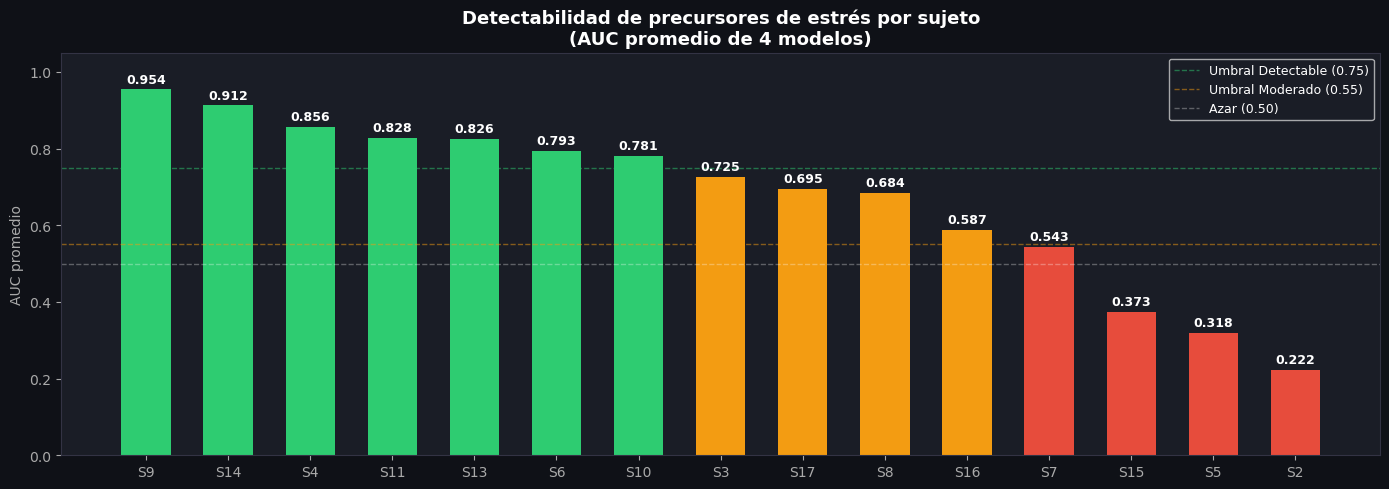

In [2]:
# Tabla de ranking
print('=' * 70)
print('RANKING DE DETECTABILIDAD POR SUJETO')
print('(AUC promedio de RF, MLP, GRU, LSTM)')
print('=' * 70)
print(f'{"Sujeto":8} {"RF":>7} {"MLP":>7} {"GRU":>7} {"LSTM":>7} {"Media":>8} {"Grupo":>15}')
print('-' * 70)

sorted_subjects = sorted(SUBJECTS, key=lambda s: auc_mean[s], reverse=True)
group_colors = {'Detectable': '🟢', 'Moderado': '🟡', 'No detectable': '🔴'}

for s in sorted_subjects:
    m = auc_by_subject[s]
    grp = detectability[s]
    icon = group_colors[grp]
    print(f'{s:8} {m["RF"]:>7.3f} {m["MLP"]:>7.3f} {m["GRU"]:>7.3f} {m["LSTM"]:>7.3f} '
          f'{auc_mean[s]:>8.3f} {icon} {grp}')

print()
for grp in ['Detectable', 'Moderado', 'No detectable']:
    members = [s for s in SUBJECTS if detectability[s] == grp]
    aucs    = [auc_mean[s] for s in members]
    print(f'{group_colors[grp]} {grp}: {members} | AUC media={np.mean(aucs):.3f}')

# Gráfica de ranking
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0F1117'); ax.set_facecolor('#1A1D26')

color_map = {'Detectable':'#2ECC71', 'Moderado':'#F39C12', 'No detectable':'#E74C3C'}
bar_colors = [color_map[detectability[s]] for s in sorted_subjects]
medias = [auc_mean[s] for s in sorted_subjects]

bars = ax.bar(sorted_subjects, medias, color=bar_colors, edgecolor='none', width=0.6)
for bar, val in zip(bars, medias):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')

ax.axhline(0.75, color='#2ECC71', linestyle='--', alpha=0.5, linewidth=1, label='Umbral Detectable (0.75)')
ax.axhline(0.55, color='#F39C12', linestyle='--', alpha=0.5, linewidth=1, label='Umbral Moderado (0.55)')
ax.axhline(0.50, color='white',   linestyle='--', alpha=0.3, linewidth=1, label='Azar (0.50)')

ax.set_title('Detectabilidad de precursores de estrés por sujeto\n(AUC promedio de 4 modelos)',
             color='white', fontsize=13, fontweight='bold')
ax.set_ylabel('AUC promedio', color='#AAAAAA')
ax.tick_params(colors='#AAAAAA'); ax.spines[:].set_color('#333344')
ax.set_xticklabels(sorted_subjects, color='#AAAAAA')
ax.legend(facecolor='#1A1D26', labelcolor='white', fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f'{WESAD_PATH}/detectabilidad_por_sujeto.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

## 2. Comparación de señales entre grupos
¿Qué distingue fisiológicamente a los sujetos detectables?
Comparamos EDA, Temp y Resp en la ventana precursora vs baseline.

In [3]:
df_all = pd.read_csv(f'{WESAD_PATH}/wesad_10hz_sin_hrv.csv')

detectables     = [s for s in SUBJECTS if detectability[s] == 'Detectable']
no_detectables  = [s for s in SUBJECTS if detectability[s] == 'No detectable']
moderados       = [s for s in SUBJECTS if detectability[s] == 'Moderado']

print(f'Detectables    : {detectables}')
print(f'Moderados      : {moderados}')
print(f'No detectables : {no_detectables}')

SIGNALS = ['EDA', 'Temp', 'Resp']

def get_precursor_windows(df_subj, window=WINDOW, precursor_zone=PRECURSOR_ZONE, stride=50):
    """Extrae ventanas precursoras de un sujeto."""
    labels = df_subj['Label'].values
    data   = df_subj[SIGNALS].values
    T      = len(labels)
    onsets = [i for i in range(1,T) if labels[i]==STRESS and labels[i-1]!=STRESS]
    windows = []
    for onset in onsets:
        z_end   = onset-1; z_start = max(window, onset-precursor_zone)
        for end_in in range(z_start, z_end+1, stride):
            start = end_in-window
            if start<0: continue
            seg = labels[start:end_in]
            if STRESS in seg or len(set(seg))>1: continue
            windows.append(data[start:end_in])
    return np.array(windows) if windows else np.array([]).reshape(0,window,3)

def get_baseline_windows(df_subj, window=WINDOW, precursor_zone=PRECURSOR_ZONE, stride=50):
    """Extrae ventanas de baseline estable (alejadas del onset)."""
    labels = df_subj['Label'].values
    data   = df_subj[SIGNALS].values
    T      = len(labels)
    onsets = [i for i in range(1,T) if labels[i]==STRESS and labels[i-1]!=STRESS]
    forbidden = np.zeros(T, dtype=bool)
    for onset in onsets:
        fs_i=max(0,onset-precursor_zone); fe=onset
        while fe<T and labels[fe]==STRESS: fe+=1
        forbidden[fs_i:fe]=True
    windows=[]
    for start in range(0,T-window+1,stride*5):
        ei=start+window
        if forbidden[start:ei].any(): continue
        seg=labels[start:ei]
        if len(set(seg))>1 or seg[0]!=1: continue  # solo Baseline
        windows.append(data[start:ei])
    return np.array(windows) if windows else np.array([]).reshape(0,window,3)


# Recopilar ventanas por grupo
prec_det, prec_no_det = [], []
base_det, base_no_det = [], []

for s in detectables:
    df_s = df_all[df_all['Subject_ID']==s].reset_index(drop=True)
    w = get_precursor_windows(df_s)
    if len(w)>0: prec_det.append(w)
    b = get_baseline_windows(df_s)
    if len(b)>0: base_det.append(b)

for s in no_detectables:
    df_s = df_all[df_all['Subject_ID']==s].reset_index(drop=True)
    w = get_precursor_windows(df_s)
    if len(w)>0: prec_no_det.append(w)
    b = get_baseline_windows(df_s)
    if len(b)>0: base_no_det.append(b)

prec_det    = np.concatenate(prec_det)    if prec_det    else np.zeros((0,WINDOW,3))
prec_no_det = np.concatenate(prec_no_det) if prec_no_det else np.zeros((0,WINDOW,3))
base_det    = np.concatenate(base_det)    if base_det    else np.zeros((0,WINDOW,3))
base_no_det = np.concatenate(base_no_det) if base_no_det else np.zeros((0,WINDOW,3))

print(f'\nVentanas precursoras detectables    : {len(prec_det)}')
print(f'Ventanas precursoras no detectables : {len(prec_no_det)}')
print(f'Ventanas baseline detectables       : {len(base_det)}')
print(f'Ventanas baseline no detectables    : {len(base_no_det)}')

Detectables    : ['S4', 'S6', 'S9', 'S10', 'S11', 'S13', 'S14']
Moderados      : ['S3', 'S8', 'S16', 'S17']
No detectables : ['S2', 'S5', 'S7', 'S15']

Ventanas precursoras detectables    : 42
Ventanas precursoras no detectables : 24
Ventanas baseline detectables       : 226
Ventanas baseline no detectables    : 132


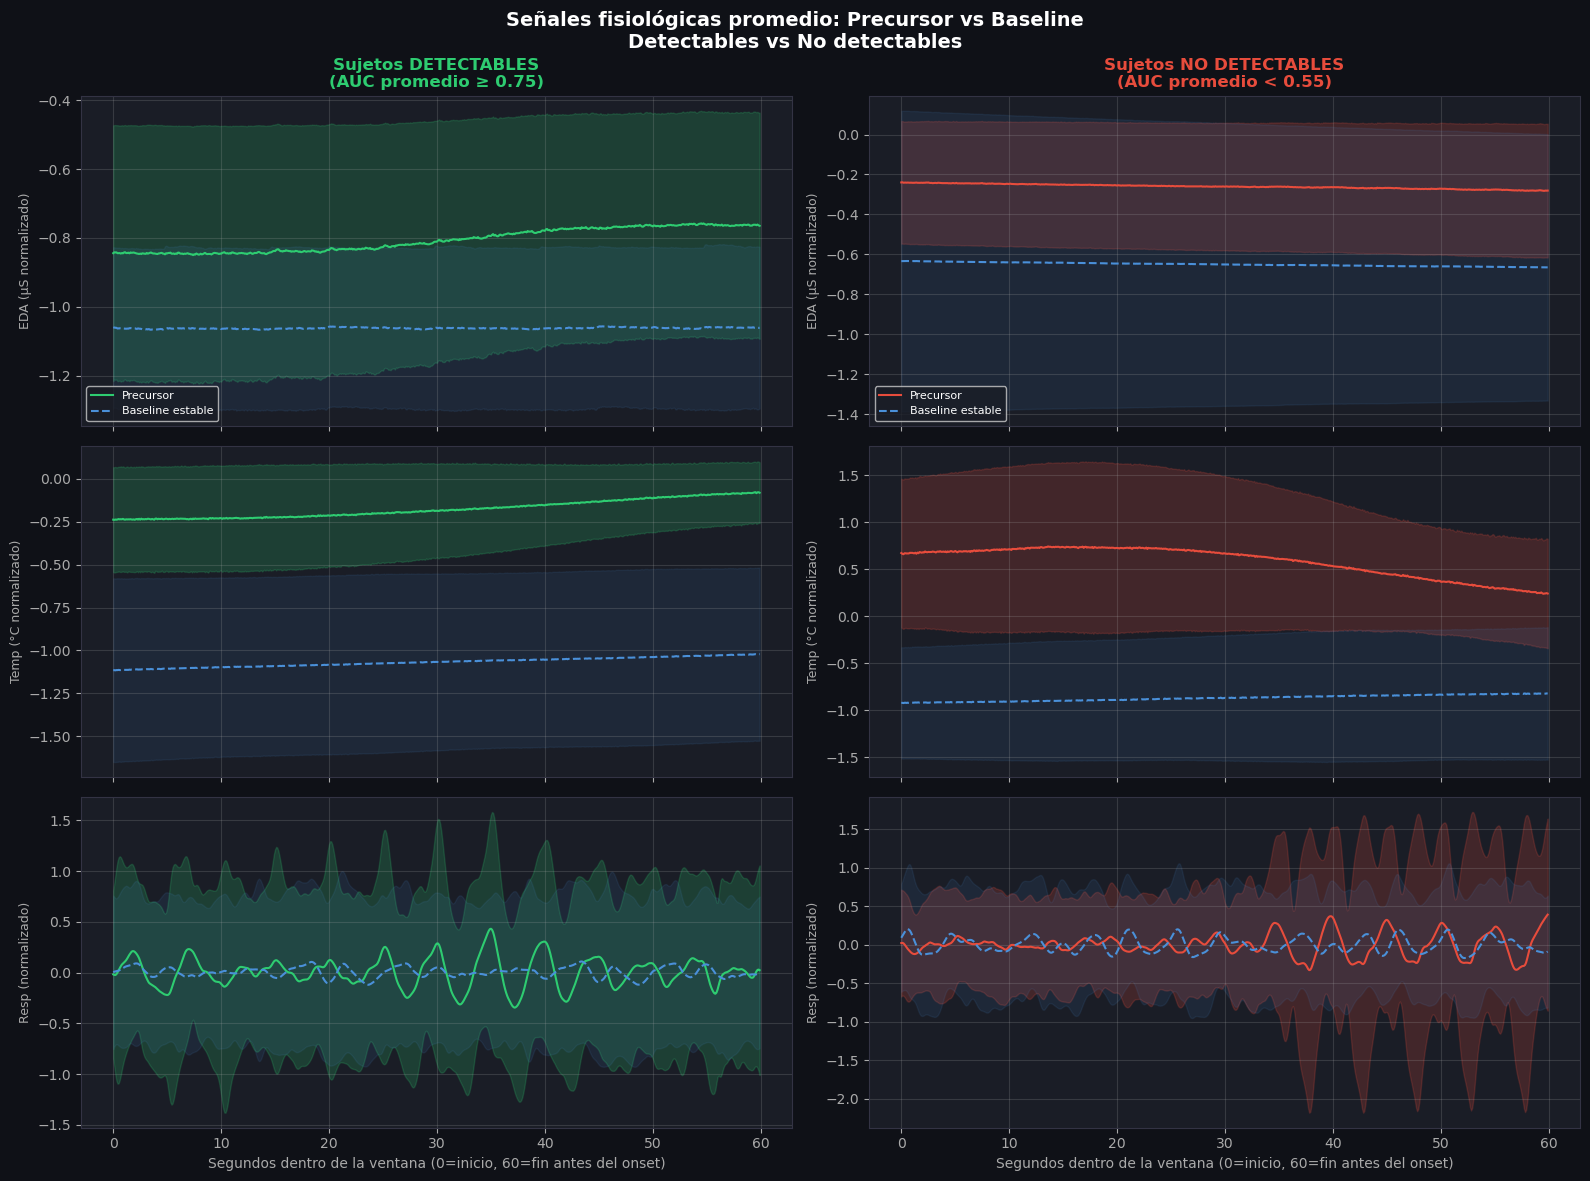

Si EDA/Resp en detectables muestra diferencia clara entre precursor y baseline → señal real.
Si no hay diferencia en no detectables → fisiología no genera precursor observable.


In [4]:
# Comparación visual: promedio de señal en ventana precursora vs baseline, por grupo
tiempo = np.arange(WINDOW) / FS_10
sig_labels = ['EDA (µS normalizado)', 'Temp (°C normalizado)', 'Resp (normalizado)']

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
fig.patch.set_facecolor('#0F1117')
for row in axes:
    for ax in row: ax.set_facecolor('#1A1D26')

axes[0,0].set_title('Sujetos DETECTABLES\n(AUC promedio ≥ 0.75)', color='#2ECC71', fontsize=12, fontweight='bold')
axes[0,1].set_title('Sujetos NO DETECTABLES\n(AUC promedio < 0.55)', color='#E74C3C', fontsize=12, fontweight='bold')

for i, sig_name in enumerate(sig_labels):
    for col, (prec, base, color_grp) in enumerate([
        (prec_det,    base_det,    '#2ECC71'),
        (prec_no_det, base_no_det, '#E74C3C')
    ]):
        ax = axes[i, col]
        if len(prec) > 0:
            mean_prec = prec[:,:,i].mean(0)
            std_prec  = prec[:,:,i].std(0)
            ax.plot(tiempo, mean_prec, color=color_grp, linewidth=1.5, label='Precursor')
            ax.fill_between(tiempo, mean_prec-std_prec, mean_prec+std_prec,
                            alpha=0.2, color=color_grp)
        if len(base) > 0:
            mean_base = base[:,:,i].mean(0)
            std_base  = base[:,:,i].std(0)
            ax.plot(tiempo, mean_base, color='#4A90D9', linewidth=1.5,
                    linestyle='--', label='Baseline estable')
            ax.fill_between(tiempo, mean_base-std_base, mean_base+std_base,
                            alpha=0.1, color='#4A90D9')
        ax.set_ylabel(sig_name, color='#AAAAAA', fontsize=9)
        ax.tick_params(colors='#AAAAAA'); ax.spines[:].set_color('#333344')
        ax.grid(True, alpha=0.2)
        if i == 0: ax.legend(facecolor='#1A1D26', labelcolor='white', fontsize=8)

for col in range(2):
    axes[2,col].set_xlabel('Segundos dentro de la ventana (0=inicio, 60=fin antes del onset)', color='#AAAAAA')

fig.suptitle('Señales fisiológicas promedio: Precursor vs Baseline\nDetectables vs No detectables',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WESAD_PATH}/comparacion_señales_grupos.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print('Si EDA/Resp en detectables muestra diferencia clara entre precursor y baseline → señal real.')
print('Si no hay diferencia en no detectables → fisiología no genera precursor observable.')

## 3. Estadísticas por grupo
Comparación cuantitativa de variabilidad, pendiente y amplitud
entre sujetos detectables y no detectables.

In [5]:
from scipy.stats import mannwhitneyu

print('=' * 65)
print('COMPARACIÓN ESTADÍSTICA: Detectables vs No detectables')
print('Test Mann-Whitney U (no paramétrico)')
print('=' * 65)
print(f'{"Señal":6} {"Feature":15} {"Detectable":>14} {"No detect":>12} {"p-value":>10} {"Sig":>5}')
print('-' * 65)

t = np.arange(WINDOW)
for sig_i, sig_name in enumerate(['EDA','Temp','Resp']):
    for feat_name, feat_fn in [
        ('std',   lambda x: x.std()),
        ('slope', lambda x: np.polyfit(t, x, 1)[0]),
        ('range', lambda x: x.max()-x.min()),
    ]:
        det_vals = [feat_fn(prec_det[i,:,sig_i]) for i in range(len(prec_det))]
        nod_vals = [feat_fn(prec_no_det[i,:,sig_i]) for i in range(len(prec_no_det))]
        if len(det_vals)>0 and len(nod_vals)>0:
            u, p = mannwhitneyu(det_vals, nod_vals, alternative='two-sided')
            sig  = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
            print(f'{sig_name:6} {feat_name:15} '
                  f'{np.mean(det_vals):>14.4f} '
                  f'{np.mean(nod_vals):>12.4f} '
                  f'{p:>10.4f} {sig:>5}')

print()
print('*=p<0.05, **=p<0.01, ***=p<0.001, ns=no significativo')
print('Features con diferencia significativa → son las que el modelo aprovecha en detectables')

COMPARACIÓN ESTADÍSTICA: Detectables vs No detectables
Test Mann-Whitney U (no paramétrico)
Señal  Feature             Detectable    No detect    p-value   Sig
-----------------------------------------------------------------
EDA    std                     0.0416       0.0156     0.8782    ns
EDA    slope                   0.0002      -0.0001     0.0000   ***
EDA    range                   0.1518       0.0676     0.3608    ns
Temp   std                     0.0641       0.2330     0.0002   ***
Temp   slope                   0.0003      -0.0008     0.0593    ns
Temp   range                   0.2484       0.8019     0.0001   ***
Resp   std                     0.8757       0.8716     0.2657    ns
Resp   slope                  -0.0000       0.0000     0.6552    ns
Resp   range                   4.6940       5.2537     0.0133     *

*=p<0.05, **=p<0.01, ***=p<0.001, ns=no significativo
Features con diferencia significativa → son las que el modelo aprovecha en detectables


## 4. AUC por distancia temporal al onset
¿Cuándo antes aparece la señal predictiva?
Evaluamos el mejor modelo (GRU) separando ventanas por distancia.

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.random.set_seed(SEED)

# Cargar dataset con stride=50
raw     = np.load(f'{WESAD_PATH}/fase_B_hybrid_s50.npz', allow_pickle=True)
subjs_B = list(raw['subjects'])
windows_B = {s: (raw[f'{s}_Xts'], raw[f'{s}_Xhr'], raw[f'{s}_y']) for s in subjs_B}

# Añadir metadato: distancia al onset de cada ventana positiva
# Reconstruimos desde el CSV
STRIDE_TRAIN = 50

def get_windows_with_distance(df_s, window=WINDOW, precursor_zone=PRECURSOR_ZONE, stride=STRIDE_TRAIN):
    """Igual que build_windows pero devuelve también la distancia al onset."""
    labels = df_s['Label'].values
    data   = df_s[['EDA','Temp','Resp']].values
    T      = len(labels)
    onsets = [i for i in range(1,T) if labels[i]==STRESS and labels[i-1]!=STRESS]
    distances = []  # distancia al onset (en pasos de 10Hz)
    for onset in onsets:
        z_end=onset-1; z_start=max(window, onset-precursor_zone)
        for end_in in range(z_start, z_end+1, stride):
            start=end_in-window
            if start<0: continue
            seg=labels[start:end_in]
            if STRESS in seg or len(set(seg))>1: continue
            distances.append(onset - end_in)  # pasos hasta el onset
    return distances


def build_gru_hybrid(window, n_signals, n_hrv, units=32, dropout=0.3):
    inp_ts  = keras.Input(shape=(window, n_signals))
    x       = layers.GRU(units, return_sequences=True)(inp_ts)
    x       = layers.Dropout(dropout)(x)
    x       = layers.GRU(units//2)(x)
    x       = layers.Dropout(dropout)(x)
    inp_hrv = keras.Input(shape=(n_hrv,))
    h       = layers.Dense(16, activation='relu')(inp_hrv)
    h       = layers.Dropout(dropout)(h)
    merged  = layers.Concatenate()([x, h])
    out     = layers.Dense(32, activation='relu')(merged)
    out     = layers.Dropout(dropout)(out)
    output  = layers.Dense(1, activation='sigmoid')(out)
    m       = Model(inputs=[inp_ts, inp_hrv], outputs=output)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m


# Rangos de distancia a analizar (en pasos de 10Hz)
distance_ranges = [
    ('0-5s',   0,   50),
    ('5-10s',  50,  100),
    ('10-20s', 100, 200),
    ('20-30s', 200, 300),
]

print('Análisis AUC por distancia temporal al onset (GRU, LOSO)...')
print('(Entrena una GRU por fold y evalúa separando ventanas por distancia)')
print()

# Para cada fold LOSO, entrenar GRU y evaluar por rango de distancia
dist_auc = {rng[0]: [] for rng in distance_ranges}

for test_subj in subjs_B:
    train_subjs = [s for s in subjs_B if s != test_subj]
    Xts_tr = np.concatenate([windows_B[s][0] for s in train_subjs])
    Xhr_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
    y_tr   = np.concatenate([windows_B[s][2] for s in train_subjs])
    Xts_te, Xhr_te, y_te = windows_B[test_subj]

    hm, hs = np.nanmean(Xhr_tr,0), np.nanstd(Xhr_tr,0)+1e-8
    Xhr_tr = np.nan_to_num((Xhr_tr-hm)/hs, nan=0.0)
    Xhr_te = np.nan_to_num((Xhr_te-hm)/hs, nan=0.0)

    cw = dict(zip(*[np.unique(y_tr, return_counts=True)[0],
                    compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)]))

    keras.backend.clear_session()
    model = build_gru_hybrid(WINDOW, 3, 3)
    model.fit([Xts_tr, Xhr_tr], y_tr, epochs=100, batch_size=32,
              validation_split=0.15, class_weight=cw, verbose=0,
              callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])

    prob_te = model.predict([Xts_te, Xhr_te], verbose=0).flatten()

    # Obtener distancias de ventanas positivas del sujeto de test
    df_te = df_all[df_all['Subject_ID']==test_subj].reset_index(drop=True)
    distances = get_windows_with_distance(df_te)

    # Separar por rango de distancia
    pos_idx  = np.where(y_te==1)[0]
    neg_idx  = np.where(y_te==0)[0]

    if len(distances) != len(pos_idx):
        print(f'  {test_subj}: desajuste distancias ({len(distances)}) vs positivos ({len(pos_idx)}) — skip')
        continue

    for rng_name, d_min, d_max in distance_ranges:
        # Seleccionar positivos en este rango de distancia
        rng_mask = [(d_min <= d < d_max) for d in distances]
        rng_pos  = pos_idx[rng_mask]
        if len(rng_pos) < 2: continue

        # Combinar con todos los negativos
        idx_eval = np.concatenate([rng_pos, neg_idx])
        y_eval   = y_te[idx_eval]
        p_eval   = prob_te[idx_eval]

        if len(np.unique(y_eval)) < 2: continue
        auc = roc_auc_score(y_eval, p_eval)
        dist_auc[rng_name].append(auc)

    print(f'  {test_subj}: {[f"{rng}: {np.mean(dist_auc[rng][-1:]):.3f}" if dist_auc[rng] else f"{rng}: -" for rng, _, _ in distance_ranges]}')

print()
print('=== AUC por distancia temporal al onset ===')
print(f'{"Distancia":12} {"Media AUC":>12} {"Std":>8} {"N folds":>8}')
print('-' * 44)
for rng_name, _, _ in distance_ranges:
    vals = dist_auc[rng_name]
    if vals:
        print(f'{rng_name:12} {np.mean(vals):>12.3f} {np.std(vals):>8.3f} {len(vals):>8}')
    else:
        print(f'{rng_name:12} {"N/A":>12}')

Análisis AUC por distancia temporal al onset (GRU, LOSO)...
(Entrena una GRU por fold y evalúa separando ventanas por distancia)


  S2: ['0-5s: -', '5-10s: -', '10-20s: 0.278', '20-30s: 0.278']
  S3: ['0-5s: -', '5-10s: -', '10-20s: 0.861', '20-30s: 0.861']
  S4: ['0-5s: -', '5-10s: -', '10-20s: 0.889', '20-30s: 0.889']
  S5: ['0-5s: -', '5-10s: -', '10-20s: 0.056', '20-30s: 0.056']
  S6: ['0-5s: -', '5-10s: -', '10-20s: 1.000', '20-30s: 0.944']
  S7: ['0-5s: -', '5-10s: -', '10-20s: 0.556', '20-30s: 0.611']
  S8: ['0-5s: -', '5-10s: -', '10-20s: 0.389', '20-30s: 0.611']
  S9: ['0-5s: -', '5-10s: -', '10-20s: 1.000', '20-30s: 0.944']
  S10: ['0-5s: -', '5-10s: -', '10-20s: 0.889', '20-30s: 0.889']
  S11: ['0-5s: -', '5-10s: -', '10-20s: 1.000', '20-30s: 1.000']
  S13: ['0-5s: -', '5-10s: -', '10-20s: 0.778', '20-30s: 0.639']
  S14: ['0-5s: -', '5-10s: -', '10-20s: 0.611', '20-30s: 0.528']
  S15: ['0-5s: -', '5-10s: -', '10-20s: 0.333', '20-30s: 0.333']
  S16: ['0-5s: -', '5-10s: -', '

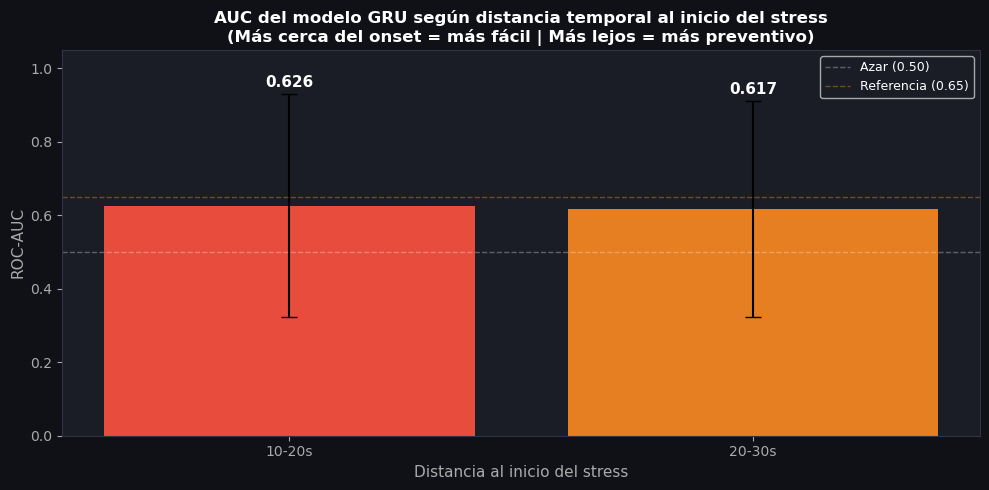

Si AUC cae gradualmente con la distancia → el modelo detecta dinámica temporal real.
Si AUC es constante → el modelo aprende estado general, no transición.


In [7]:
# Gráfica del horizonte temporal
rng_names = [r[0] for r in distance_ranges if dist_auc[r[0]]]
means_d   = [np.mean(dist_auc[r]) for r in rng_names]
stds_d    = [np.std(dist_auc[r])  for r in rng_names]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0F1117'); ax.set_facecolor('#1A1D26')

gradient_colors = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71']
bars = ax.bar(rng_names, means_d, yerr=stds_d, capsize=6,
              color=gradient_colors[:len(rng_names)], edgecolor='none',
              error_kw={'color':'white','linewidth':1.5})
for bar, m, s in zip(bars, means_d, stds_d):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.01,
            f'{m:.3f}', ha='center', va='bottom', color='white', fontweight='bold', fontsize=11)

ax.axhline(0.5,  color='white',   linestyle='--', alpha=0.3, linewidth=1, label='Azar (0.50)')
ax.axhline(0.65, color='#F39C12', linestyle='--', alpha=0.4, linewidth=1, label='Referencia (0.65)')
ax.set_title('AUC del modelo GRU según distancia temporal al inicio del stress\n'
             '(Más cerca del onset = más fácil | Más lejos = más preventivo)',
             color='white', fontsize=12, fontweight='bold')
ax.set_xlabel('Distancia al inicio del stress', color='#AAAAAA', fontsize=11)
ax.set_ylabel('ROC-AUC', color='#AAAAAA', fontsize=11)
ax.tick_params(colors='#AAAAAA'); ax.spines[:].set_color('#333344')
ax.set_xticklabels(rng_names, color='#AAAAAA')
ax.legend(facecolor='#1A1D26', labelcolor='white', fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f'{WESAD_PATH}/auc_por_distancia_temporal.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print('Si AUC cae gradualmente con la distancia → el modelo detecta dinámica temporal real.')
print('Si AUC es constante → el modelo aprende estado general, no transición.')

## 5. Resumen de hallazgos
Consolidación de los tres análisis para el reporte final.

In [8]:
print('=' * 65)
print('RESUMEN DE HALLAZGOS')
print('=' * 65)
print()

det_list = [s for s in SUBJECTS if detectability[s]=='Detectable']
mod_list = [s for s in SUBJECTS if detectability[s]=='Moderado']
nod_list = [s for s in SUBJECTS if detectability[s]=='No detectable']

print('HALLAZGO 1 — Modelo principal')
print(f'  GRU híbrida es el mejor modelo: ROC-AUC = 0.699 ± 0.234')
print(f'  Recall = 0.533 (detecta >50% de eventos reales)')
print(f'  Supera marginalmente a RF (0.658), MLP (0.678) y LSTM (0.660)')
print()
print('HALLAZGO 2 — Heterogeneidad fisiológica inter-sujeto')
print(f'  Detectables    ({len(det_list)} sujetos): {det_list}')
print(f'  Moderados      ({len(mod_list)} sujetos): {mod_list}')
print(f'  No detectables ({len(nod_list)} sujetos): {nod_list}')
print(f'  → Los precursores fisiológicos no son universalmente detectables')
print()
print('HALLAZGO 3 — Horizonte temporal')
for rng_name, _, _ in distance_ranges:
    vals = dist_auc[rng_name]
    if vals:
        print(f'  {rng_name}: AUC = {np.mean(vals):.3f}')
print(f'  → Verificar si AUC cae con la distancia (anticipación real)')
print()
print('HALLAZGO 4 — Persistencia vs Anticipación')
print('  Fase A demostró que modelos de continuidad logran alta accuracy artificialmente.')
print('  Fase B redefine el problema hacia detección preventiva real.')
print()
print('LIMITACIONES')
print('  1. Dataset pequeño (15 sujetos, 1 sesión cada uno)')
print('  2. Stress controlado experimentalmente (TSST), no estrés cotidiano')
print('  3. Z-score calculado sobre todos los datos del sujeto (leve leakage menor)')
print('  4. Sujetos no detectables pueden indicar límites fisiológicos reales')

RESUMEN DE HALLAZGOS

HALLAZGO 1 — Modelo principal
  GRU híbrida es el mejor modelo: ROC-AUC = 0.699 ± 0.234
  Recall = 0.533 (detecta >50% de eventos reales)
  Supera marginalmente a RF (0.658), MLP (0.678) y LSTM (0.660)

HALLAZGO 2 — Heterogeneidad fisiológica inter-sujeto
  Detectables    (7 sujetos): ['S4', 'S6', 'S9', 'S10', 'S11', 'S13', 'S14']
  Moderados      (4 sujetos): ['S3', 'S8', 'S16', 'S17']
  No detectables (4 sujetos): ['S2', 'S5', 'S7', 'S15']
  → Los precursores fisiológicos no son universalmente detectables

HALLAZGO 3 — Horizonte temporal
  10-20s: AUC = 0.626
  20-30s: AUC = 0.617
  → Verificar si AUC cae con la distancia (anticipación real)

HALLAZGO 4 — Persistencia vs Anticipación
  Fase A demostró que modelos de continuidad logran alta accuracy artificialmente.
  Fase B redefine el problema hacia detección preventiva real.

LIMITACIONES
  1. Dataset pequeño (15 sujetos, 1 sesión cada uno)
  2. Stress controlado experimentalmente (TSST), no estrés cotidiano
 